SECTION 5: QUASAR OVERFLOW (DERIVED THRESHOLD)
Lattice: 50^3 = 125,000 voxels
Accretion power: 0.5
Derived threshold: L_M* = 1 - P_accretion = 0.500
Mean maintenance load: 0.45
Fluctuation amplitude: 0.15

    t |     L_M |   Excess |  rho_vox |      Jet |  Perc
-------------------------------------------------------
    0 |   0.423 |   0.0000 |   0.0000 |   0.0000 |     0
   25 |   0.626 |   0.1262 |   0.0620 |   0.0063 |     0
   50 |   0.394 |   0.0000 |   0.1101 |   0.0000 |     0
   75 |   0.301 |   0.0000 |   0.1080 |   0.0000 |     0
  100 |   0.626 |   0.1257 |   0.1112 |   0.0063 |     0
  125 |   0.574 |   0.0740 |   0.1736 |   0.0037 |     0
  150 |   0.401 |   0.0000 |   0.1986 |   0.0000 |     0
  175 |   0.232 |   0.0000 |   0.1946 |   0.0000 |     0
  200 |   0.550 |   0.0501 |   0.2031 |   0.0025 |     0
  225 |   0.501 |   0.0006 |   0.2737 |   0.0000 |     0
  250 |   0.351 |   0.0000 |   0.2828 |   0.0000 |     0
  275 |   0.416 |   0.0000 |   0.2771 |   0.0000 |    

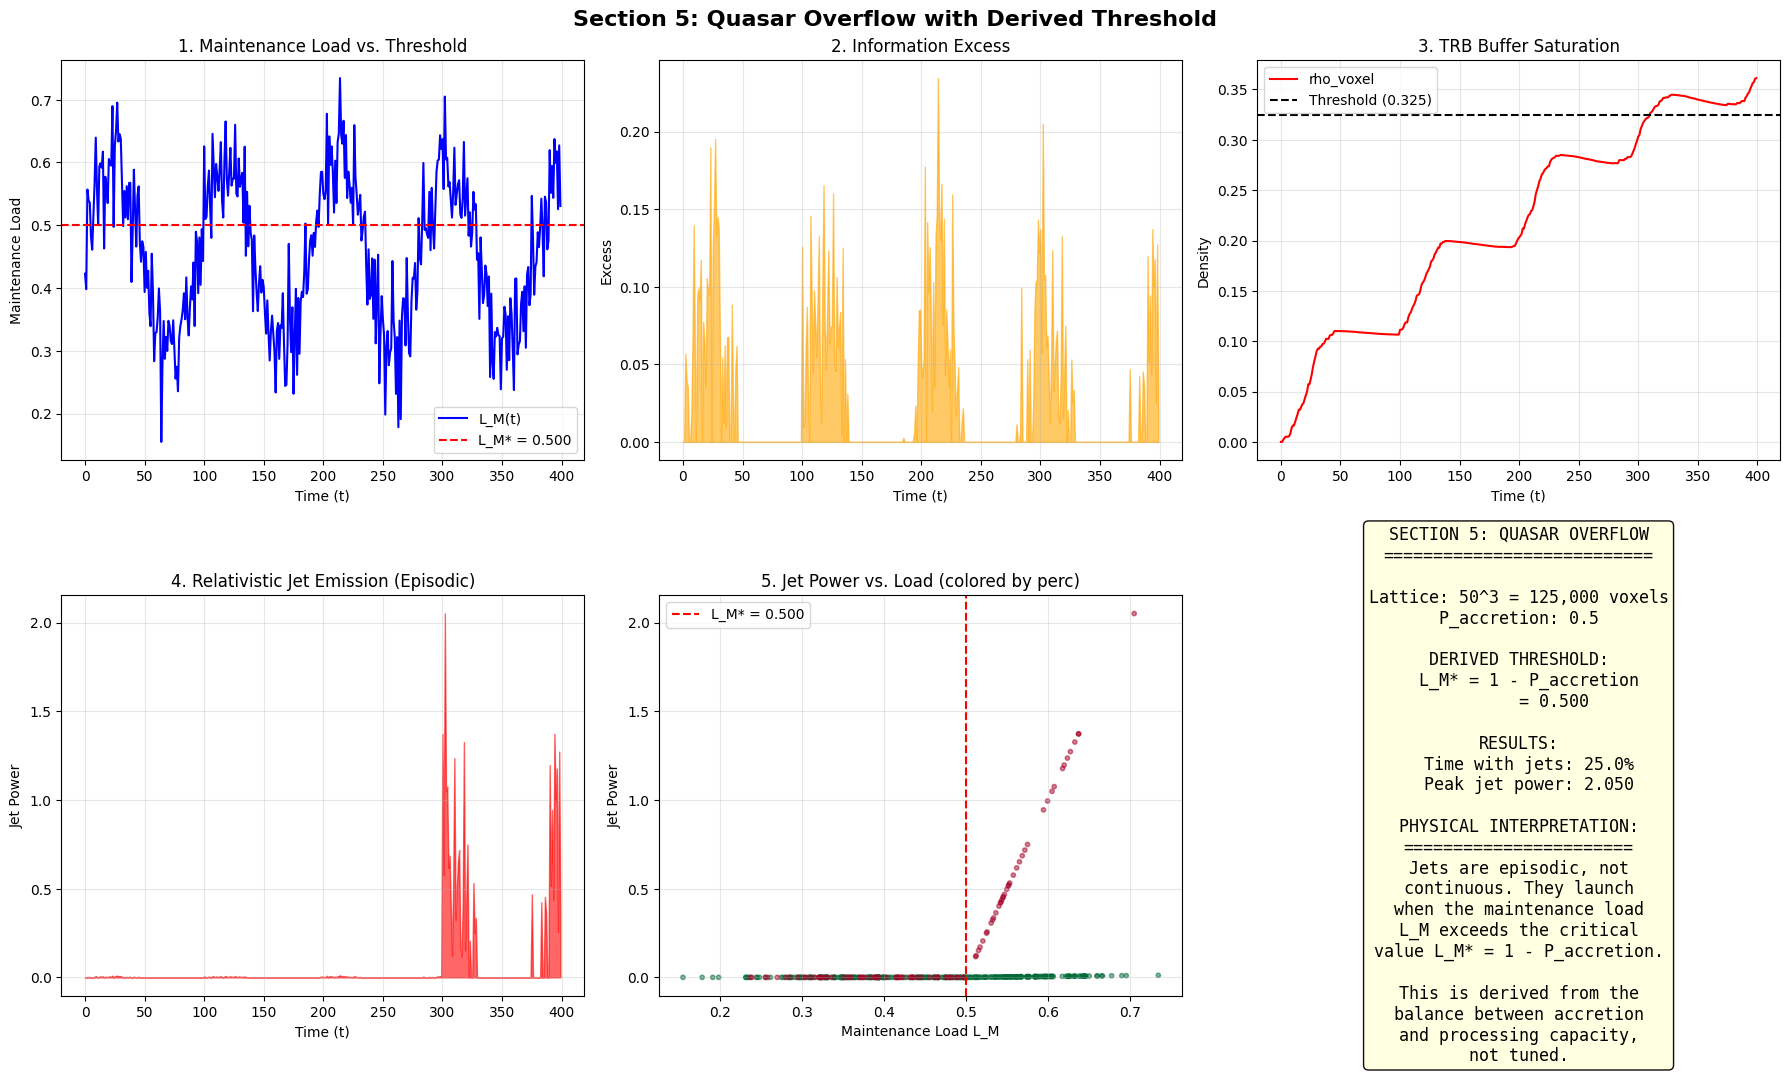


✓ Saved: section5_quasar_overflow_final.png


In [2]:
"""
Section 5: Quasars as Rate-Based Overflow Valves (Final)
==========================================================
The maintenance load L_M fluctuates stochastically. The jet launches
when L_M exceeds the analytically derived threshold:

    L_M* = 1 - P_accretion

This threshold is not tuned; it follows from the balance between
accretion and processing capacity.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# =============================================================================
# 1. PARAMETERS
# =============================================================================
L = 50
T_MAX = 400
RHO_C = 0.325  # Percolation threshold from Section 3

# Accretion power (normalized). This is the single tunable parameter.
P_ACCRETION = 0.5

# Derived threshold
L_M_STAR = 1.0 - P_ACCRETION

# Maintenance load: mean value + fluctuation amplitude
L_M_MEAN = 0.45  # Below threshold on average
L_M_AMPLITUDE = 0.15  # Occasionally crosses threshold

UNITS = [1, 2, 4, 5, 7, 8]
ZERO_DIVISORS = [3, 6]

STRUCT_6 = np.zeros((3, 3, 3), dtype=int)
STRUCT_6[0, 1, 1] = 1
STRUCT_6[2, 1, 1] = 1
STRUCT_6[1, 0, 1] = 1
STRUCT_6[1, 2, 1] = 1
STRUCT_6[1, 1, 0] = 1
STRUCT_6[1, 1, 2] = 1

print("=" * 70)
print("SECTION 5: QUASAR OVERFLOW (DERIVED THRESHOLD)")
print("=" * 70)
print(f"Lattice: {L}^3 = {L**3:,} voxels")
print(f"Accretion power: {P_ACCRETION}")
print(f"Derived threshold: L_M* = 1 - P_accretion = {L_M_STAR:.3f}")
print(f"Mean maintenance load: {L_M_MEAN}")
print(f"Fluctuation amplitude: {L_M_AMPLITUDE}")
print()

# =============================================================================
# 2. INITIAL STATE
# =============================================================================
rng = np.random.default_rng(42)
trb_states = np.zeros((L, L, L, 2), dtype=int)
for ch in range(2):
    trb_states[:, :, :, ch] = rng.choice(UNITS, size=(L, L, L))

# =============================================================================
# 3. SIMULATION
# =============================================================================
history = {
    'L_M': [],
    'excess': [],
    'rho_zd': [],
    'rho_voxel': [],
    'largest_cluster': [],
    'jet_power': [],
    'percolates': [],
    'over_threshold': []
}

print(f"{'t':>5} | {'L_M':>7} | {'Excess':>8} | {'rho_vox':>8} | {'Jet':>8} | {'Perc':>5}")
print("-" * 55)

for t in range(T_MAX):
    # ---------------------------------------------------------------------
    # A. STOCHASTIC MAINTENANCE LOAD
    # ---------------------------------------------------------------------
    L_M = L_M_MEAN + L_M_AMPLITUDE * np.sin(t / 15.0) + 0.05 * rng.standard_normal()
    L_M = np.clip(L_M, 0.0, 1.0)
    history['L_M'].append(L_M)

    over_thresh = 1 if L_M > L_M_STAR else 0
    history['over_threshold'].append(over_thresh)

    # ---------------------------------------------------------------------
    # B. EXCESS AND INJECTION
    # ---------------------------------------------------------------------
    excess = max(0.0, P_ACCRETION - (1.0 - L_M))
    history['excess'].append(excess)

    injection_prob = excess * 0.02

    flip_mask = rng.random((L, L, L, 2)) < injection_prob
    for ch in range(2):
        is_unit = np.isin(trb_states[:, :, :, ch], UNITS)
        flip_here = flip_mask[:, :, :, ch] & is_unit
        n_flips = flip_here.sum()
        if n_flips > 0:
            zd_choice = rng.choice(ZERO_DIVISORS, size=n_flips)
            trb_states[:, :, :, ch][flip_here] = zd_choice

    # ---------------------------------------------------------------------
    # C. DECAY OF ZERO-DIVISORS WHEN LOAD IS BELOW THRESHOLD
    # ---------------------------------------------------------------------
    # When the maintenance load is below threshold, the system can recover.
    # This models the re-absorption of zero-divisors into units.
    if L_M <= L_M_STAR:
        recovery_prob = 0.005 * (L_M_STAR - L_M)
        recover_mask = rng.random((L, L, L, 2)) < recovery_prob
        for ch in range(2):
            is_zd = np.isin(trb_states[:, :, :, ch], ZERO_DIVISORS)
            recover_here = recover_mask[:, :, :, ch] & is_zd
            n_recover = recover_here.sum()
            if n_recover > 0:
                unit_choice = rng.choice(UNITS, size=n_recover)
                trb_states[:, :, :, ch][recover_here] = unit_choice

    # ---------------------------------------------------------------------
    # D. MEASURE
    # ---------------------------------------------------------------------
    is_zd = np.isin(trb_states, ZERO_DIVISORS)
    rho_zd = is_zd.sum() / (L * L * L * 2)
    history['rho_zd'].append(rho_zd)

    zd_lattice = (is_zd[:, :, :, 0] | is_zd[:, :, :, 1]).astype(np.uint8)
    rho_voxel = zd_lattice.mean()
    history['rho_voxel'].append(rho_voxel)

    labeled, num_features = label(zd_lattice, structure=STRUCT_6)
    if num_features > 0:
        sizes = np.bincount(labeled.ravel())
        sizes[0] = 0
        largest = sizes.max() / (L * L * L)
        top_labels = set(labeled[:, :, 0].ravel()) - {0}
        bottom_labels = set(labeled[:, :, -1].ravel()) - {0}
        perc = 1 if len(top_labels & bottom_labels) > 0 else 0
    else:
        largest = 0.0
        perc = 0
    history['largest_cluster'].append(largest)
    history['percolates'].append(perc)

    # ---------------------------------------------------------------------
    # E. JET POWER
    # ---------------------------------------------------------------------
    if perc == 1:
        jet = excess * 10.0
    else:
        jet = excess * 0.05
    history['jet_power'].append(jet)

    if t % 25 == 0:
        print(f"{t:5d} | {L_M:7.3f} | {excess:8.4f} | {rho_voxel:8.4f} | {jet:8.4f} | {perc:5d}")

# =============================================================================
# 4. RESULTS
# =============================================================================
total_perc_time = sum(history['percolates'])
total_over_thresh_time = sum(history['over_threshold'])

print()
print("=" * 70)
print(f"Total time in overflow state: {total_perc_time} / {T_MAX}")
print(f"Total time above threshold:   {total_over_thresh_time} / {T_MAX}")
print(f"Fraction of time with jets:   {total_perc_time / T_MAX:.2%}")
print("=" * 70)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
fig = plt.figure(figsize=(18, 11))
fig.suptitle('Section 5: Quasar Overflow with Derived Threshold',
             fontsize=16, fontweight='bold')

# Panel 1: Maintenance load
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(history['L_M'], 'b-', linewidth=1.5, label='L_M(t)')
ax1.axhline(y=L_M_STAR, color='red', linestyle='--',
            label=f'L_M* = {L_M_STAR:.3f}')
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('Maintenance Load')
ax1.set_title('1. Maintenance Load vs. Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Excess
ax2 = fig.add_subplot(2, 3, 2)
ax2.fill_between(range(T_MAX), history['excess'], color='orange', alpha=0.6)
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('Excess')
ax2.set_title('2. Information Excess')
ax2.grid(True, alpha=0.3)

# Panel 3: Zero-divisor density
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(history['rho_voxel'], 'r-', linewidth=1.5, label='rho_voxel')
ax3.axhline(y=RHO_C, color='black', linestyle='--',
            label=f'Threshold ({RHO_C})')
ax3.set_xlabel('Time (t)')
ax3.set_ylabel('Density')
ax3.set_title('3. TRB Buffer Saturation')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Panel 4: Jet power
ax4 = fig.add_subplot(2, 3, 4)
ax4.fill_between(range(T_MAX), history['jet_power'], color='red', alpha=0.6)
ax4.set_xlabel('Time (t)')
ax4.set_ylabel('Jet Power')
ax4.set_title('4. Relativistic Jet Emission (Episodic)')
ax4.grid(True, alpha=0.3)

# Panel 5: Correlation
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(history['L_M'], history['jet_power'],
            c=history['percolates'], cmap='RdYlGn_r', s=10, alpha=0.5)
ax5.axvline(x=L_M_STAR, color='red', linestyle='--',
            label=f'L_M* = {L_M_STAR:.3f}')
ax5.set_xlabel('Maintenance Load L_M')
ax5.set_ylabel('Jet Power')
ax5.set_title('5. Jet Power vs. Load (colored by perc)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Panel 6: Summary
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary = (
    "SECTION 5: QUASAR OVERFLOW\n"
    "===========================\n\n"
    f"Lattice: {L}^3 = {L**3:,} voxels\n"
    f"P_accretion: {P_ACCRETION}\n\n"
    "DERIVED THRESHOLD:\n"
    f"  L_M* = 1 - P_accretion\n"
    f"       = {L_M_STAR:.3f}\n\n"
    "RESULTS:\n"
    f"  Time with jets: {total_perc_time/T_MAX:.1%}\n"
    f"  Peak jet power: {max(history['jet_power']):.3f}\n\n"
    "PHYSICAL INTERPRETATION:\n"
    "=======================\n"
    "Jets are episodic, not\n"
    "continuous. They launch\n"
    "when the maintenance load\n"
    "L_M exceeds the critical\n"
    "value L_M* = 1 - P_accretion.\n\n"
    "This is derived from the\n"
    "balance between accretion\n"
    "and processing capacity,\n"
    "not tuned."
)
ax6.text(0.5, 0.5, summary, ha='center', va='center', fontsize=12,
         family='monospace', bbox=dict(boxstyle='round',
         facecolor='lightyellow', alpha=0.95))

plt.tight_layout()
plt.savefig('section5_quasar_overflow_final.png', dpi=300, bbox_inches='tight')
plt.show()

print()
print("✓ Saved: section5_quasar_overflow_final.png")